# Experiment- run tau sweep

to use for visuals


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

from violmulti.experiments.experiment import load_experiment
from violmulti.experiments.experiment_tau_sweep import ExperimentTauSweep
from violmulti.models.multiclass_logistic_regression import MultiClassLogisticRegression
from violmulti.features.design_matrix_generator_PWM import *
from violmulti.visualizations.model_visualizer import ModelVisualizerTauSweep

from violmulti.data import ANIMAL_IDS
from violmulti.experiments import STANDARD_SIGMAS, STANDARD_TAUS
import config as c
sns.set_context("talk")
%load_ext autoreload
%autoreload 2

In [2]:
STANDARD_TAUS

[0.51, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30, 40, 50, 100]

In [3]:
standard_cols = {
    "session": lambda df: (copy(df.session)),
    "bias": lambda df: (add_bias_column(df)),
    "s_a": lambda df: (standardize(df.s_a)),
    "s_b": lambda df: (standardize(df.s_b)),
    "prev_stim_avg": lambda df: (prev_avg_stim(df, mask_prev_violation=False)),
    "prev_correct": lambda df: (prev_correct_side(df)),
    "prev_choice": lambda df: (prev_choice(df)),
    "labels": multi_choice_labels(),
}

sweep_col = {
    "tau_sweep": {
        "taus": STANDARD_TAUS,
        "col_name": "filt_prev_violation",
        "col_func": lambda df: prev_violation(df),
        "current_idx": 0,
    },
}

model_config = {
    "tau_sweep_prev_filt_violation": {
        "model_class": MultiClassLogisticRegression,
        "dmg_config": {**standard_cols, **sweep_col},
    }
}

params = {
    "animals": ANIMAL_IDS,  # all animals
    "data_type": "new_trained_cleaned",
    "sigmas": STANDARD_SIGMAS,
    "random_state": 47,
    "eval_train": True,
    "model_config": model_config,
}
save_name = "2025_07_19_fig3_sweep_prev_viol_taus_rs47.pkl"

## Run


In [4]:
experiment = ExperimentTauSweep(params)
experiment.run()
experiment.save(save_name, file_path=c.MODEL_FITS_PATH)

Loading dataset type : new_trained_cleaned
DataLoader: Loading data type:  new_trained_cleaned  for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']

 >>>> evaluating animal W051 sweeping taus of [0.51, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30, 40, 50, 100] <<<<

 ***** evaluating tau 0.51, sigma 0.07 *****
         Current function value: 64583.184501
         Iterations: 27
         Function evaluations: 76
         Gradient evaluations: 68

 ***** evaluating tau 0.51, sigma 0.13 *****
         Current function value: 64328.661452
         Iterations: 25
         Function evaluations: 94
         Gradient evaluations: 82

 ***** evaluating tau 0.51, sigma 0.25 *****
Optimization terminated successfully.
         Current function value: 64250.134309
         Iterations: 27
         Function evaluations: 42
         Gradient evaluations: 42

 ***** evaluating tau 0.51, sigma 0.5 *****


## Visualize


In [ ]:
exp = load_experiment(save_name, save_path=c.MODEL_FITS_PATH)
mvt = ModelVisualizerTauSweep(exp)
mvt.save_best_fit_tau(var_name="prev_violation", save_path=c.MODEL_FITS_PATH + "/taus_df.csv")


Saved prev_violation_tau taus to taus_df.csv


In [6]:
mvt.fit_models

,animal_id,model_name,model_type,nll,train_nll,sigma,features,weights,n_train_trials,n_test_trials,tau
0,W051,tau_sweep_prev_filt_violation,multi,15282.956889,64234.045949,0.07,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.30739859155938415, 0.3599622521231892, -0....",79660,19100,0.51
1,W051,tau_sweep_prev_filt_violation,multi,15278.349433,64221.916774,0.13,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.30673260342269565, 0.36079263016635515, -0...",79660,19100,0.51
2,W051,tau_sweep_prev_filt_violation,multi,15277.506078,64220.788392,0.25,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.3065720770548958, 0.36113140201124466, -0....",79660,19100,0.51
3,W051,tau_sweep_prev_filt_violation,multi,15277.320202,64220.702585,0.50,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.3065310715888715, 0.3612341500498033, -0.6...",79660,19100,0.51
4,W051,tau_sweep_prev_filt_violation,multi,15277.277154,64220.697180,1.00,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.3065210751561671, 0.3612604432521489, -0.6...",79660,19100,0.51
...,...,...,...,...,...,...,...,...,...,...,...
2731,W094,tau_sweep_prev_filt_violation,multi,9885.049917,45783.311859,1.00,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.34793117182597516, 0.32158904374483627, -0...",54039,11751,100.00
2732,W094,tau_sweep_prev_filt_violation,multi,9884.996204,45783.305772,2.00,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.3486157684443722, 0.32195098826749496, -0....",54039,11751,100.00
2733,W094,tau_sweep_prev_filt_violation,multi,9884.982991,45783.305389,4.00,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.3487876315403523, 0.3220418162975757, -0.6...",54039,11751,100.00
2734,W094,tau_sweep_prev_filt_violation,multi,9884.979702,45783.305365,8.00,"Index(['bias', 's_a', 's_b', 'prev_stim_avg', ...","[[0.34883064213608256, 0.3220645447710195, -0....",54039,11751,100.00


In [7]:
mvt.find_best_fit(group="animal_id")[["animal_id", "tau"]]

,animal_id,tau
0,W051,1.0
1,W060,1.0
2,W065,3.0
3,W066,15.0
4,W068,30.0
5,W072,1.0
6,W073,2.0
7,W074,3.0
8,W075,12.0
9,W078,1.0


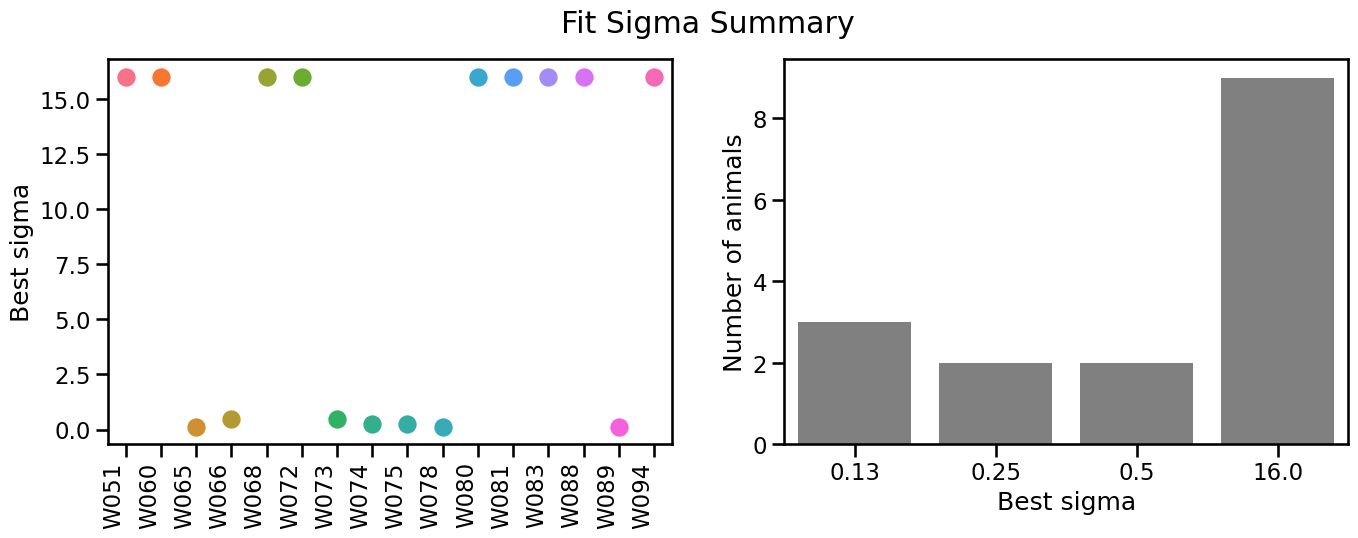

In [8]:
mvt.plot_sigma_summary()

/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:753: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:766: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


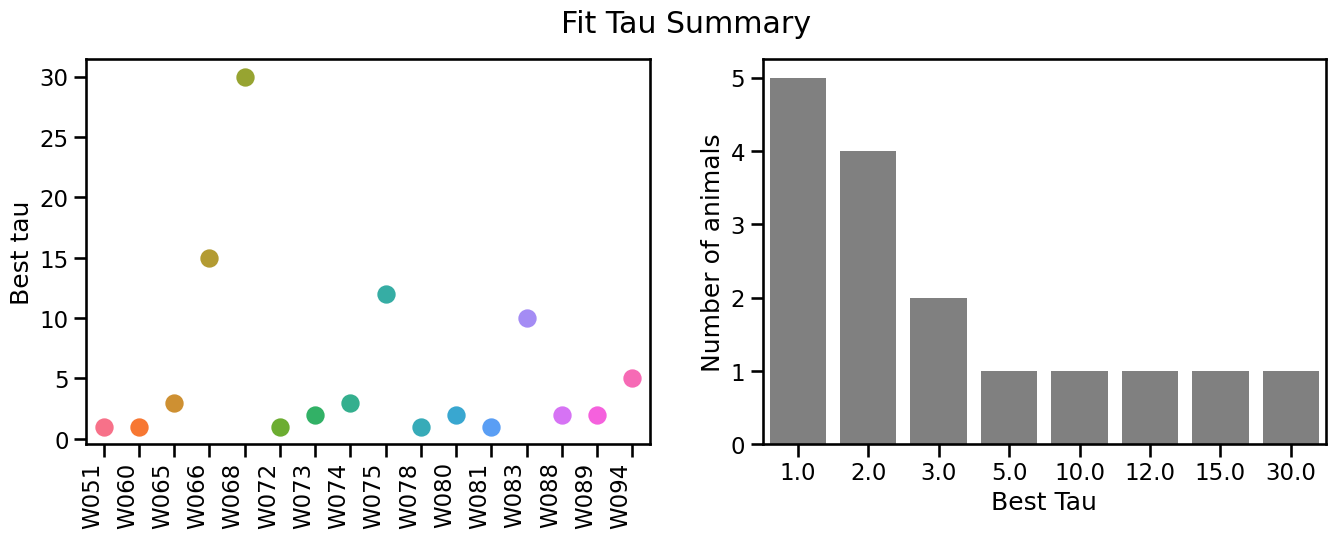

In [9]:
mvt.plot_tau_summary()

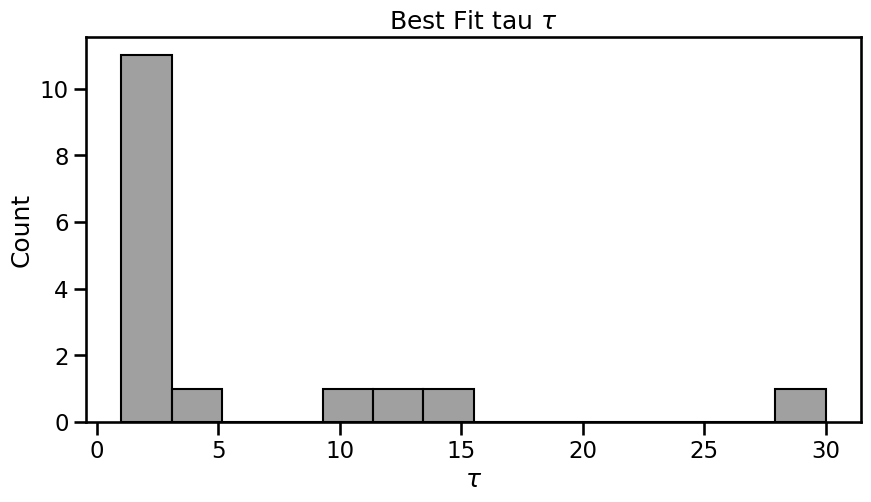

In [10]:
mvt.plot_tau_histogram(column="tau", binwidth=2)

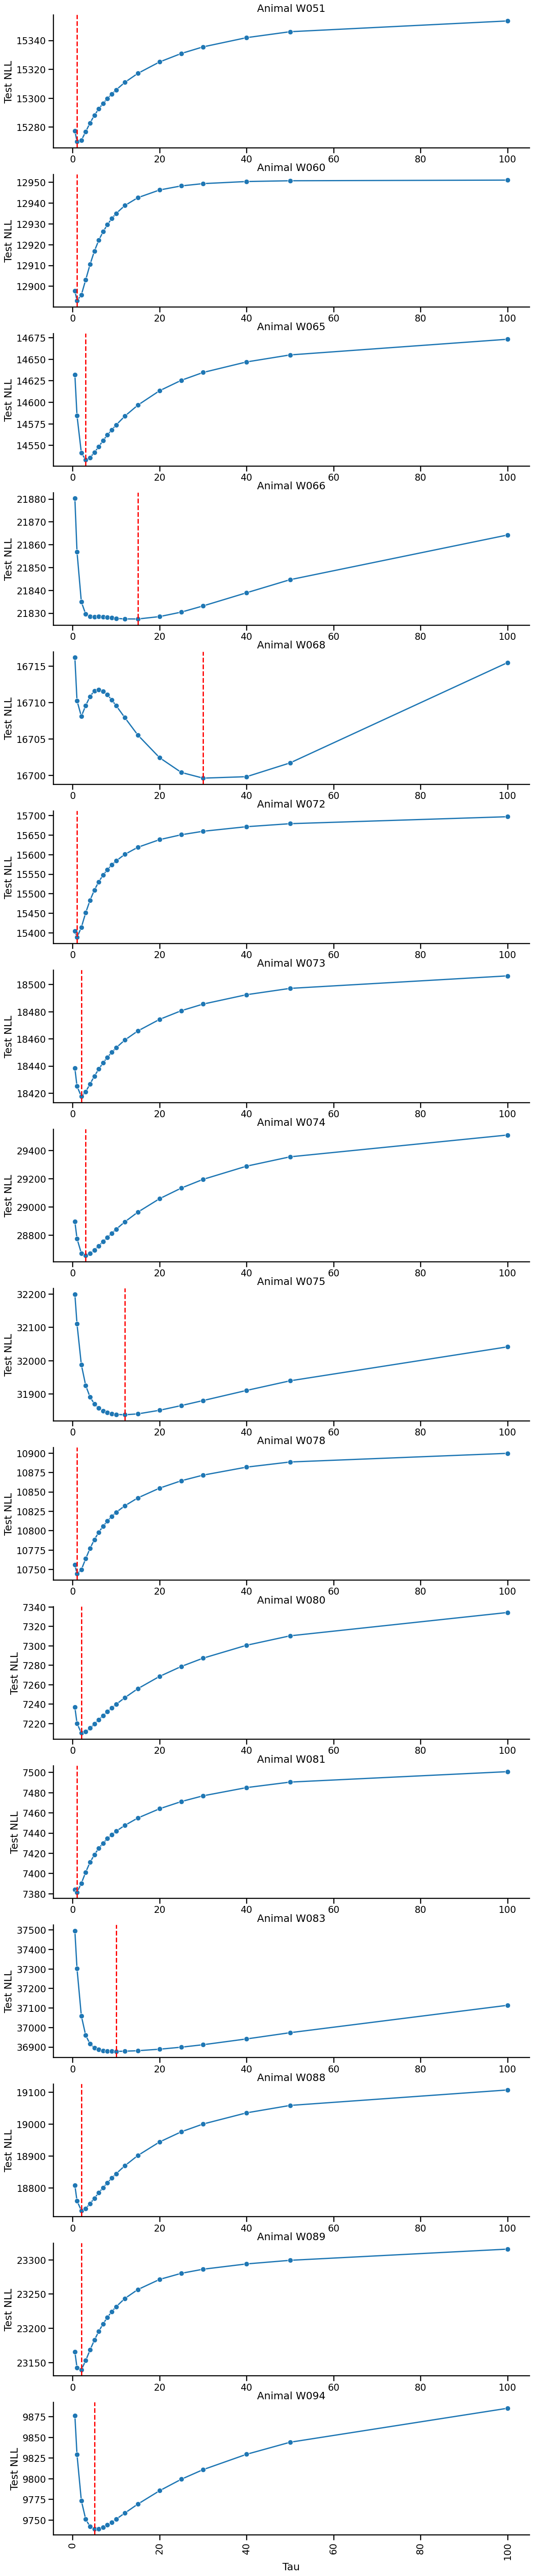

In [11]:
mvt.plot_nll_over_taus_by_animal()



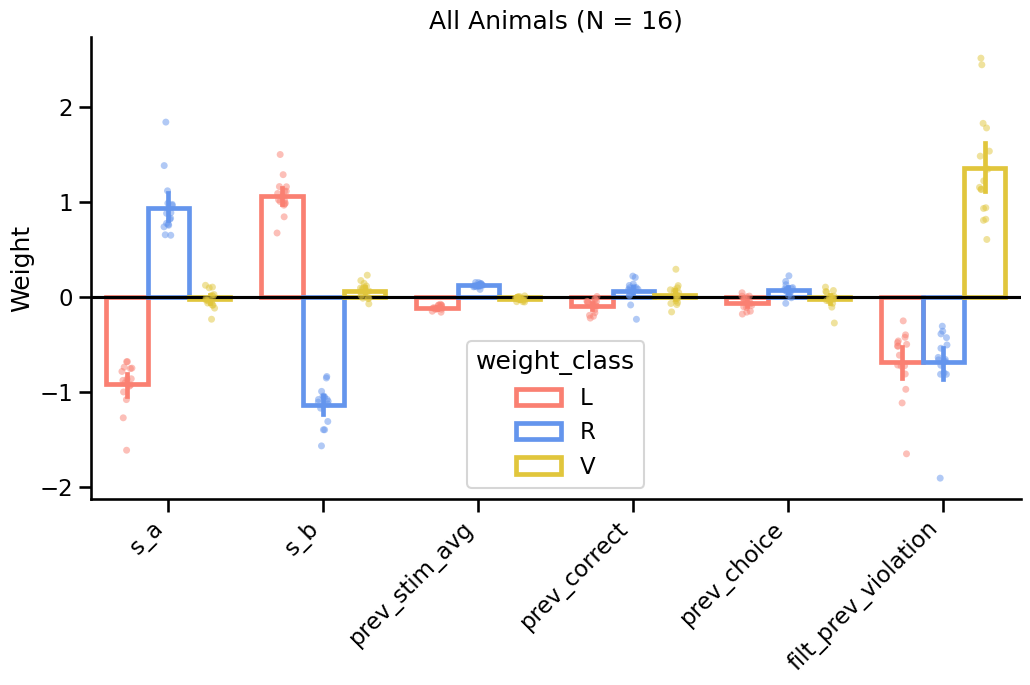

In [16]:
mvt.plot_weights_summary(palette=c.MULTI_CHOICE_PAL, plot_individuals=True)